<a href="https://colab.research.google.com/github/serendipity343/Machine-learning/blob/Task-1%262/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction
This colab worksheet provides a starting point for Task 2 (the computer vision task).

In [ ]:
import google
google.colab.drive.mount('/content/gdrive')

Mounted at /content/gdrive


# Data Loading

In [ ]:
# Download the data stored in a zipped numpy array from one of these two locations
# If you're running all your experiments
# on a machine at home rather than using colab, then make sure you save it
# rather than repeatedly downloading it.

!wget "https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5" -O face_alignment_training_images.npz

# The test images (without points)
!wget "https://sussex.box.com/shared/static/8n5ofhb9so0ia85g4bbcmnt3h6z53m9a" -O face_alignment_test_images.npz

--2025-04-03 13:08:07--  https://sussex.box.com/shared/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.box.com (sussex.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.box.com (sussex.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-04-03 13:08:07--  https://sussex.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Reusing existing connection to sussex.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5 [following]
--2025-04-03 13:08:08--  https://sussex.app.box.com/public/static/wrlmcs47dstkmfz2eckgg5d2l0liusr5
Resolving sussex.app.box.com (sussex.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to sussex.app.box.com (sussex.app.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting resp

# Check the data downloaded correctly
If any of these assertions fail, redownload the data

In [ ]:
def confirm_checksum(filename, true_checksum):
  import subprocess
  checksum = subprocess.check_output(['shasum',filename]).decode('utf-8')
  print (checksum)
  assert checksum.split(' ')[0] == true_checksum, 'Checksum does not match for ' + filename + ' redownload the data.'

confirm_checksum('face_alignment_training_images.npz', 'affc56216e34c827f10681a14c602981c06ddeb3')
confirm_checksum('face_alignment_test_images.npz', 'e480535442512b8175ae110d2d3e507378cabbdb')



affc56216e34c827f10681a14c602981c06ddeb3  face_alignment_training_images.npz

e480535442512b8175ae110d2d3e507378cabbdb  face_alignment_test_images.npz



# Load the data

In [ ]:
import numpy as np


# Load the data using np.load
data = np.load('/content/gdrive/MyDrive/350/face_alignment_training_images.npz', allow_pickle=True)

# Extract the images
images = data['images']
# and the data points
pts = data['points']

print(images.shape, pts.shape)

test_data = np.load('/content/gdrive/MyDrive/350/face_alignment_test_images.npz', allow_pickle=True)
test_images = test_data['images']
print(test_images.shape)

(2811, 256, 256, 3) (2811, 5, 2)
(554, 256, 256, 3)


# Data Visualisation
Here's an example of how to display the images and their points

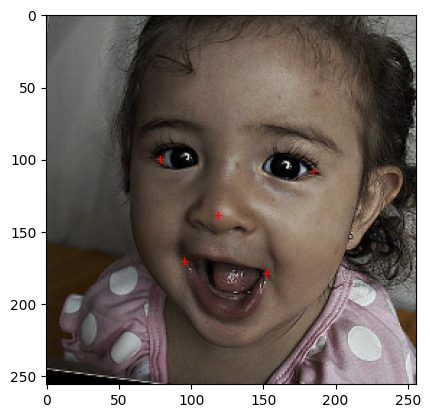

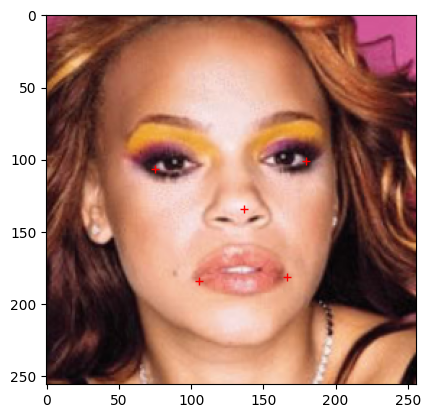

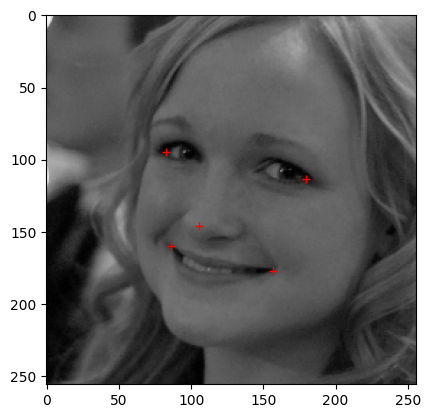

In [ ]:
def visualise_pts(img, pts):
  import matplotlib.pyplot as plt
  plt.imshow(img)
  plt.plot(pts[:, 0], pts[:, 1], '+r')
  plt.show()

for i in range(3):
  idx = np.random.randint(0, images.shape[0])
  visualise_pts(images[idx, ...], pts[idx, ...])

# Calculating Prediction Error and exporting results

In [ ]:
def euclid_dist(pred_pts, gt_pts):
  """
  Calculate the euclidean distance between pairs of points
  :param pred_pts: The predicted points
  :param gt_pts: The ground truth points
  :return: An array of shape (no_points,) containing the distance of each predicted point from the ground truth
  """
  import numpy as np
  pred_pts = np.reshape(pred_pts, (-1, 2))
  gt_pts = np.reshape(gt_pts, (-1, 2))
  return np.sqrt(np.sum(np.square(pred_pts - gt_pts), axis=-1))


In [ ]:
def save_as_csv(points, location = '.'):
    """
    Save the points out as a .csv file
    :param points: numpy array of shape (no_test_images, no_points, 2) to be saved
    :param location: Directory to save results.csv in. Default to current working directory
    """
    assert points.shape[0]==554, 'wrong number of image points, should be 554 test images'
    assert np.prod(points.shape[1:])==5*2, 'wrong number of points provided. There should be 5 points with 2 values (x,y) per point'
    np.savetxt(location + '/results_task2.csv', np.reshape(points, (points.shape[0], -1)), delimiter=',')


In [ ]:
import cv2
# Initialize SIFT feature extractor
sift = cv2.SIFT_create()

In [ ]:
def extract_sift_features(image, grid_size=5):
    # Convert to grayscale if image has 3 channels
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    h, w = image.shape
    keypoints = []

    step_x, step_y = w // grid_size, h // grid_size
    for y in range(step_y // 2, h, step_y):
        for x in range(step_x // 2, w, step_x):
            keypoints.append(cv2.KeyPoint(x, y, 1))

    sift = cv2.SIFT_create()
    _, descriptors = sift.compute(image, keypoints)

    if descriptors is None:
        descriptors = np.zeros((grid_size * grid_size, 128))
    return descriptors.flatten()



In [ ]:
# Extract features
X = np.array([extract_sift_features(img) for img in images])
y = pts.reshape(len(pts), -1)

In [ ]:
# Train/Validation split
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Train model
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
model = MultiOutputRegressor(Ridge(alpha=1.0))
model.fit(X_train, y_train)

MultiOutputRegressor(estimator=Ridge())

In [ ]:
# Predict on validation set and analyze
y_val_pred = model.predict(X_val)
val_errors = np.linalg.norm(y_val_pred - y_val, axis=1)

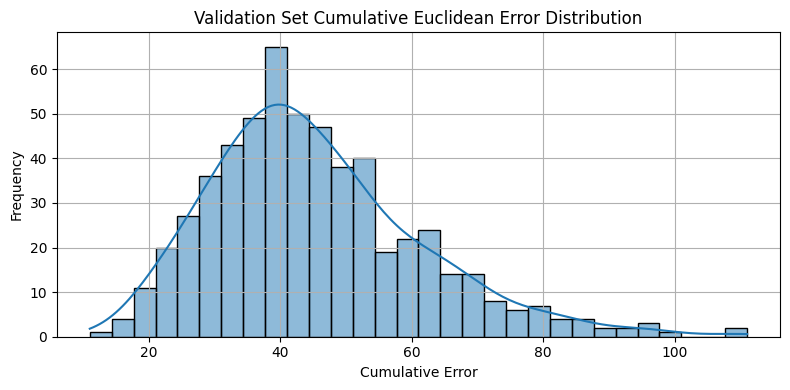

In [ ]:
# Plot validation error distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.histplot(val_errors, bins=30, kde=True)
plt.title("Validation Set Cumulative Euclidean Error Distribution")
plt.xlabel("Cumulative Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Predict on test set
X_test = np.array([extract_sift_features(img) for img in test_images])
y_test_pred = model.predict(X_test)
y_test_pred = y_test_pred.reshape(test_images.shape[0], 5, 2)


In [ ]:
# Save predictions
save_as_csv(y_test_pred, location='/content/gdrive/MyDrive/350')